In [1]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight = "balanced", random_state= 42)
logreg.fit(X_train, y_train)

In [6]:
y_pred = logreg.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



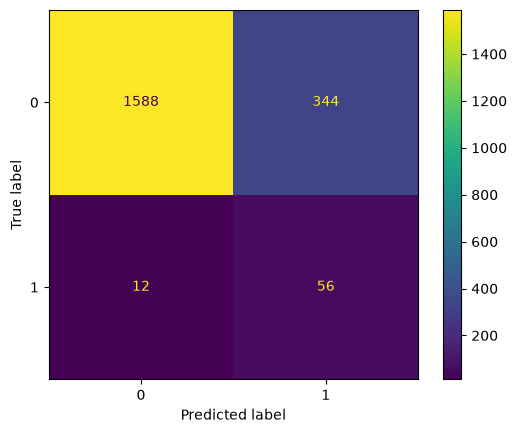

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.85      0.50      0.63        68

    accuracy                           0.98      2000
   macro avg       0.92      0.75      0.81      2000
weighted avg       0.98      0.98      0.98      2000



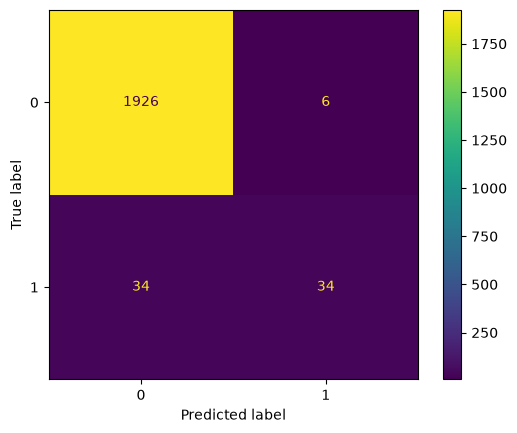

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

## Model Comparison

The models show a trade-off between detecting failures and avoiding false alarms. Since missed failures are important in predictive maintenance, recall and F1-score for the failure class are prioritized over accuracy alone.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Precision,Recall,F1
0,Logistic Regression,0.14,0.823529,0.239316
1,Random Forest,0.85,0.500000,0.629630


## Handling Class Imbalance

Machine failures are much less frequent than non-failures. We use class weighting to give more importance to the minority failure class during training.

In [13]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.74      0.68      0.71        68

    accuracy                           0.98      2000
   macro avg       0.87      0.83      0.85      2000
weighted avg       0.98      0.98      0.98      2000



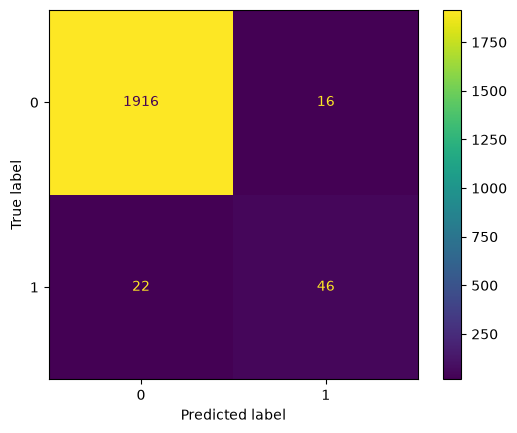

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced)

In [16]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

In [17]:
grid.best_params_

{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}

In [18]:
y_pred_tuned = grid.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.78      0.67        68

    accuracy                           0.97      2000
   macro avg       0.79      0.88      0.83      2000
weighted avg       0.98      0.97      0.98      2000



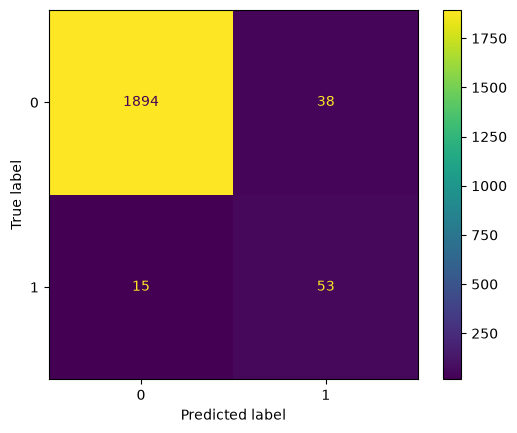

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



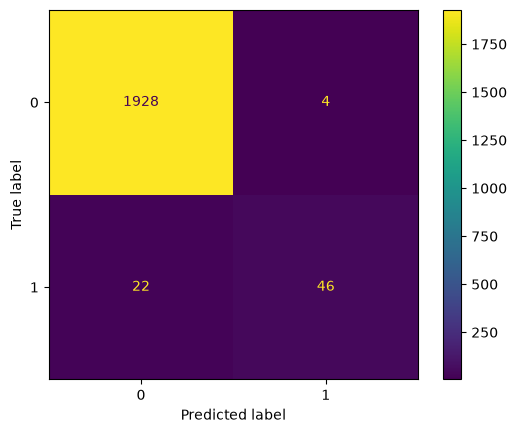

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)

In [23]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbos

In [24]:
grid.best_params_, grid.best_score_

({'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200},
 np.float64(0.7292978657861516))

In [25]:
gb_tuned = grid.best_estimator_
y_pred_tuned = gb_tuned.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.84      0.71      0.77        68

    accuracy                           0.99      2000
   macro avg       0.92      0.85      0.88      2000
weighted avg       0.98      0.99      0.98      2000



### Model Selection

Gradient Boosting achieved the best failure-class F1-score (0.78). Hyperparameter tuning with 5-fold cross-validation did not improve the F1-score. Therefore, the original Gradient Boosting model was selected as the final model.

<Axes: title={'center': 'Feature Importance'}>

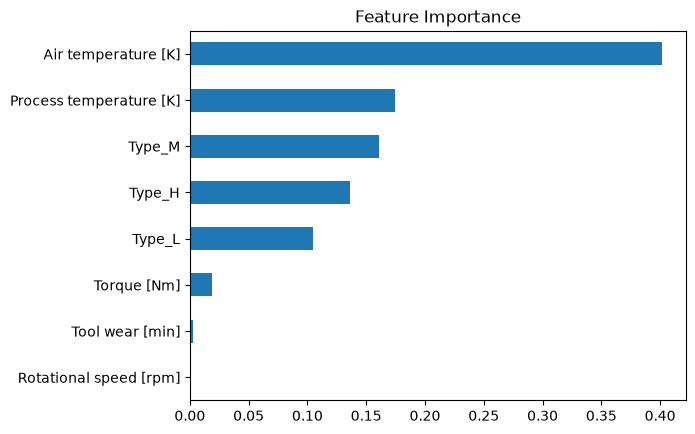

In [28]:
importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values()

importance.plot.barh(title="Feature Importance")

In [29]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(gb, "../models/gradient_boosting_model.pkl")

['../models/gradient_boosting_model.pkl']